# Previsão de Resultado de Partidas de League of Legends

## Projeto Final — Módulo 43 | Case 03 — Riot Games

---

### 🎯 Objetivo do Projeto
Desenvolver um **modelo de Machine Learning** capaz de prever o **time vencedor** de uma partida de League of Legends com base em dados coletados durante os primeiros minutos de jogo (estado pós-início de partida).
 
### 📋 Escopo Técnico
| Item | Detalhe |
|------|---------|
| **Problema** | Classificação binária — Time Azul vence (1) ou perde (0) |
| **Dados** | ~9.879 partidas ranqueadas com 40 variáveis |
| **Modelos** | Regressão Logística, Naive Bayes, Árvore de Decisão, Random Forest, Gradient Boosting |
| **Métrica principal** | AUC-ROC (solicitado pelo stakeholder) |
| **Bônus** | Cross-validation, Ensemble, GridSearchCV, App Streamlit |
 
### ✍️ Índice
1. Setup e Importações
2. Carregamento e Entendimento dos Dados
3. Análise Exploratória de Dados (EDA)
4. Preparação dos Dados e Feature Engineering
5. Modelagem
6. Avaliação Comparativa
7. Ajuste de Hiperparâmetros (Tuning)
8. Insights, Conclusões e Recomendações

# 1. Setup e Importações

In [80]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn: pré-processamento
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler

# Scikit-learn: modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn: métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Persistência de modelos
import joblib
import os

In [81]:
# Configurações globais de visualização
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 11,
    }
)
sns.set_palette("deep")

In [82]:
# Constantes do projeto
BLUE = "#1f77b4"  # Time Azul — vitória
RED = "#d62728"  # Time Vermelho — derrota
GREEN = "#2ca02c"  # Métricas positivas
AMBER = "#ff7f0e"  # Destaques / atenção
PURPLE = "#9467bd"  # Ensemble
RANDOM_STATE = 42

In [83]:
# Pastas de saída
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# 2. Carregamento e Entendimento dos Dados
 
### 📖 Dicionário de Variáveis (40 colunas)
 
O dataset registra o estado da partida em um ponto pós-início de jogo (~10 min). Toda variável com prefixo **`blue`** tem uma equivalente em **`red`**, exceto a target. Total: 1 identificador + 1 target + 19 features × 2 times = 40 colunas.
 
| Variável (prefixo `blue`/`red`) | Tipo | Descrição |
|----------------------------------|------|-----------|
| `gameId` | int | Identificador único da partida *(coluna única, sem prefixo)* |
| `blueWins` | int (0/1) | **TARGET** — 1 se o Time Azul venceu *(coluna única, sem equivalente red)* |
| `WardsPlaced` | int | Wards colocadas (visão no mapa) |
| `WardsDestroyed` | int | Wards inimigas destruídas |
| `FirstBlood` | int (0/1) | Se o time obteve o primeiro abate da partida |
| `Kills` | int | Total de campeões abatidos |
| `Deaths` | int | Total de mortes do time (= Kills do time adversário) |
| `Assists` | int | Total de assistências em abates |
| `EliteMonsters` | int | Monstros elite capturados (Dragões + Arautos somados) |
| `Dragons` | int | Dragões capturados |
| `Heralds` | int | Arautos (Heralds) capturados |
| `TowersDestroyed` | int | Torres inimigas destruídas |
| `TotalGold` | int | Ouro total acumulado pelo time |
| `AvgLevel` | float | Nível médio dos campeões do time |
| `TotalExperience` | int | Experiência total acumulada pelo time |
| `TotalMinionsKilled` | int | Total de minions (creeps de lane) abatidos — *farm* |
| `TotalJungleMinionsKilled` | int | Total de monstros de selva abatidos — *farm de jungle* |
| `GoldDiff` | int | Diferença de ouro em relação ao time adversário (blue − red) |
| `ExperienceDiff` | int | Diferença de experiência em relação ao adversário (blue − red) |
| `CSPerMin` | float | CS (minions + jungle) por minuto — eficiência de farm |
| `GoldPerMin` | float | Ouro ganho por minuto |
 
> ⚠️ Note que `redGoldDiff` = −`blueGoldDiff` e `redExperienceDiff` = −`blueExperienceDiff` (espelhos exatos), e `blueDeaths` = `redKills` enquanto `redDeaths` = `blueKills`. Essas redundâncias serão tratadas na seção de Preparação dos Dados.

In [84]:
# carregar o dataset
DATASET_PATH = "data/raw/Base_M43_Pratique_LOL_RANKED_WIN.csv"
df = pd.read_csv(DATASET_PATH)
df

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,...,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,...,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,...,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,...,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


In [85]:
# Tipos de dados
print(df.dtypes.value_counts().to_string())
df.dtypes

int64      34
float64     6


gameId                            int64
blueWins                          int64
blueWardsPlaced                   int64
blueWardsDestroyed                int64
blueFirstBlood                    int64
blueKills                         int64
blueDeaths                        int64
blueAssists                       int64
blueEliteMonsters                 int64
blueDragons                       int64
blueHeralds                       int64
blueTowersDestroyed               int64
blueTotalGold                     int64
blueAvgLevel                    float64
blueTotalExperience               int64
blueTotalMinionsKilled            int64
blueTotalJungleMinionsKilled      int64
blueGoldDiff                      int64
blueExperienceDiff                int64
blueCSPerMin                    float64
blueGoldPerMin                  float64
redWardsPlaced                    int64
redWardsDestroyed                 int64
redFirstBlood                     int64
redKills                          int64


In [86]:
# Valores nulos
df.isnull().sum()

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

Nenhum valor nulo encontrado! Dataset completamente limpo.

In [87]:
# Estatísticas descritivas (amostra)
df[
    [
        "blueKills",
        "blueTotalGold",
        "blueGoldDiff",
        "blueExperienceDiff",
        "blueDragons",
        "blueHeralds",
    ]
].describe().round(2)

,blueKills,blueTotalGold,blueGoldDiff,blueExperienceDiff,blueDragons,blueHeralds
count,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00
mean,6.18,16503.46,14.41,-33.62,0.36,0.19
std,3.01,1535.45,2453.35,1920.37,0.48,0.39
min,0.00,10730.00,-10830.00,-9333.00,0.00,0.00
25%,4.00,15415.50,-1585.50,-1290.50,0.00,0.00
50%,6.00,16398.00,14.00,-28.00,0.00,0.00
75%,8.00,17459.00,1596.00,1212.00,1.00,0.00
max,22.00,23701.00,11467.00,8348.00,1.00,1.00


In [88]:
# Análise da variável target (blueWins)
var_target = df["blueWins"].value_counts().sort_index()

print("Distribuição da variável target (blueWins):\n")
print(f"  Derrota do Time Azul (0): {var_target[0]:,} ({var_target[0] / len(df):.1%})")
print(f"  Vitória do Time Azul  (1): {var_target[1]:,} ({var_target[1] / len(df):.1%})")

Distribuição da variável target (blueWins):

  Derrota do Time Azul (0): 4,949 (50.1%)
  Vitória do Time Azul  (1): 4,930 (49.9%)


Dataset Balanceado (≈ 50/50)

Sem necessidade de SMOTE, under-sampling ou class weighting
Accuracy é uma métrica válida aqui (além do AUC-ROC)

# 3. Análise Exploratória de Dados (EDA)

A EDA nos permite **entender os dados antes de modelar**, identificar padrões, outliers e decidir quais features são mais relevantes para o modelo. Vamos responder perguntas como:

- A distribuição das classes está balanceada?
- Quais features se correlacionam mais com a vitória?
- First blood, dragões e arautos realmente importam?
- Existe assimetria entre o lado azul e vermelho?

## Distribuição da variável

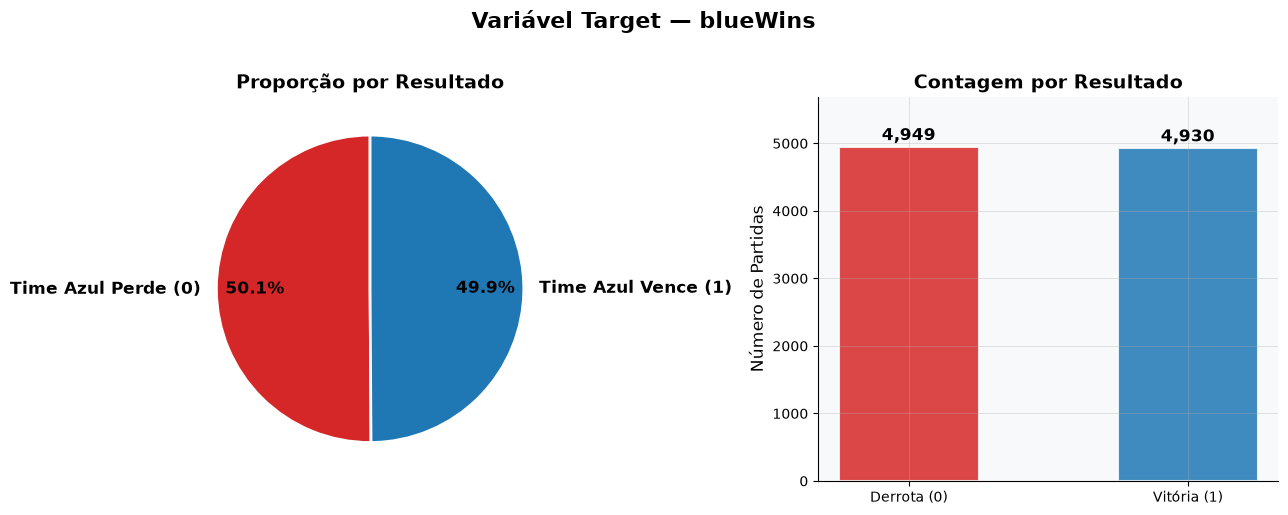

In [89]:
# Distribuição da variável target (blueWins)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie
wedge_props = {"linewidth": 2, "edgecolor": "white"}
axes[0].pie(
    var_target.values,
    labels=["Time Azul Perde (0)", "Time Azul Vence (1)"],
    colors=[RED, BLUE],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops=wedge_props,
    pctdistance=0.75,
)
axes[0].set_title("Proporção por Resultado")

# Bar
bars = axes[1].bar(
    ["Derrota (0)", "Vitória (1)"],
    var_target.values,
    color=[RED, BLUE],
    alpha=0.85,
    width=0.5,
    edgecolor="white",
    linewidth=1.5,
)
for bar, val in zip(bars, var_target.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12,
    )
axes[1].set_ylabel("Número de Partidas")
axes[1].set_title("Contagem por Resultado")
axes[1].set_ylim(0, max(var_target.values) * 1.15)

plt.suptitle("Variável Target — blueWins", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Salvar o gráfico
plt.savefig("reports/figures/01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Heatmap de correlação

In [ ]:
# Excluindo a variável gameId (não tem valor preditivo)
df_corr = df.drop(columns=["gameId"]).corr()
corr = df_corr.corr()

In [90]:
target_corr = corr["blueWins"].drop("blueWins").abs().sort_values(ascending=False)

print(target_corr)

redGoldDiff                     0.935537
blueGoldDiff                    0.935537
blueExperienceDiff              0.931688
redExperienceDiff               0.931688
redTotalExperience              0.906192
redAvgLevel                     0.900815
redTotalGold                    0.896670
redGoldPerMin                   0.896670
blueTotalExperience             0.891319
blueAvgLevel                    0.882822
blueGoldPerMin                  0.874800
blueTotalGold                   0.874800
redKills                        0.809289
blueDeaths                      0.809289
blueKills                       0.787809
redDeaths                       0.787809
redAssists                      0.774180
blueAssists                     0.759762
redTotalMinionsKilled           0.708591
redCSPerMin                     0.708591
blueCSPerMin                    0.706675
blueTotalMinionsKilled          0.706675
blueFirstBlood                  0.706022
redFirstBlood                   0.706022
redEliteMonsters

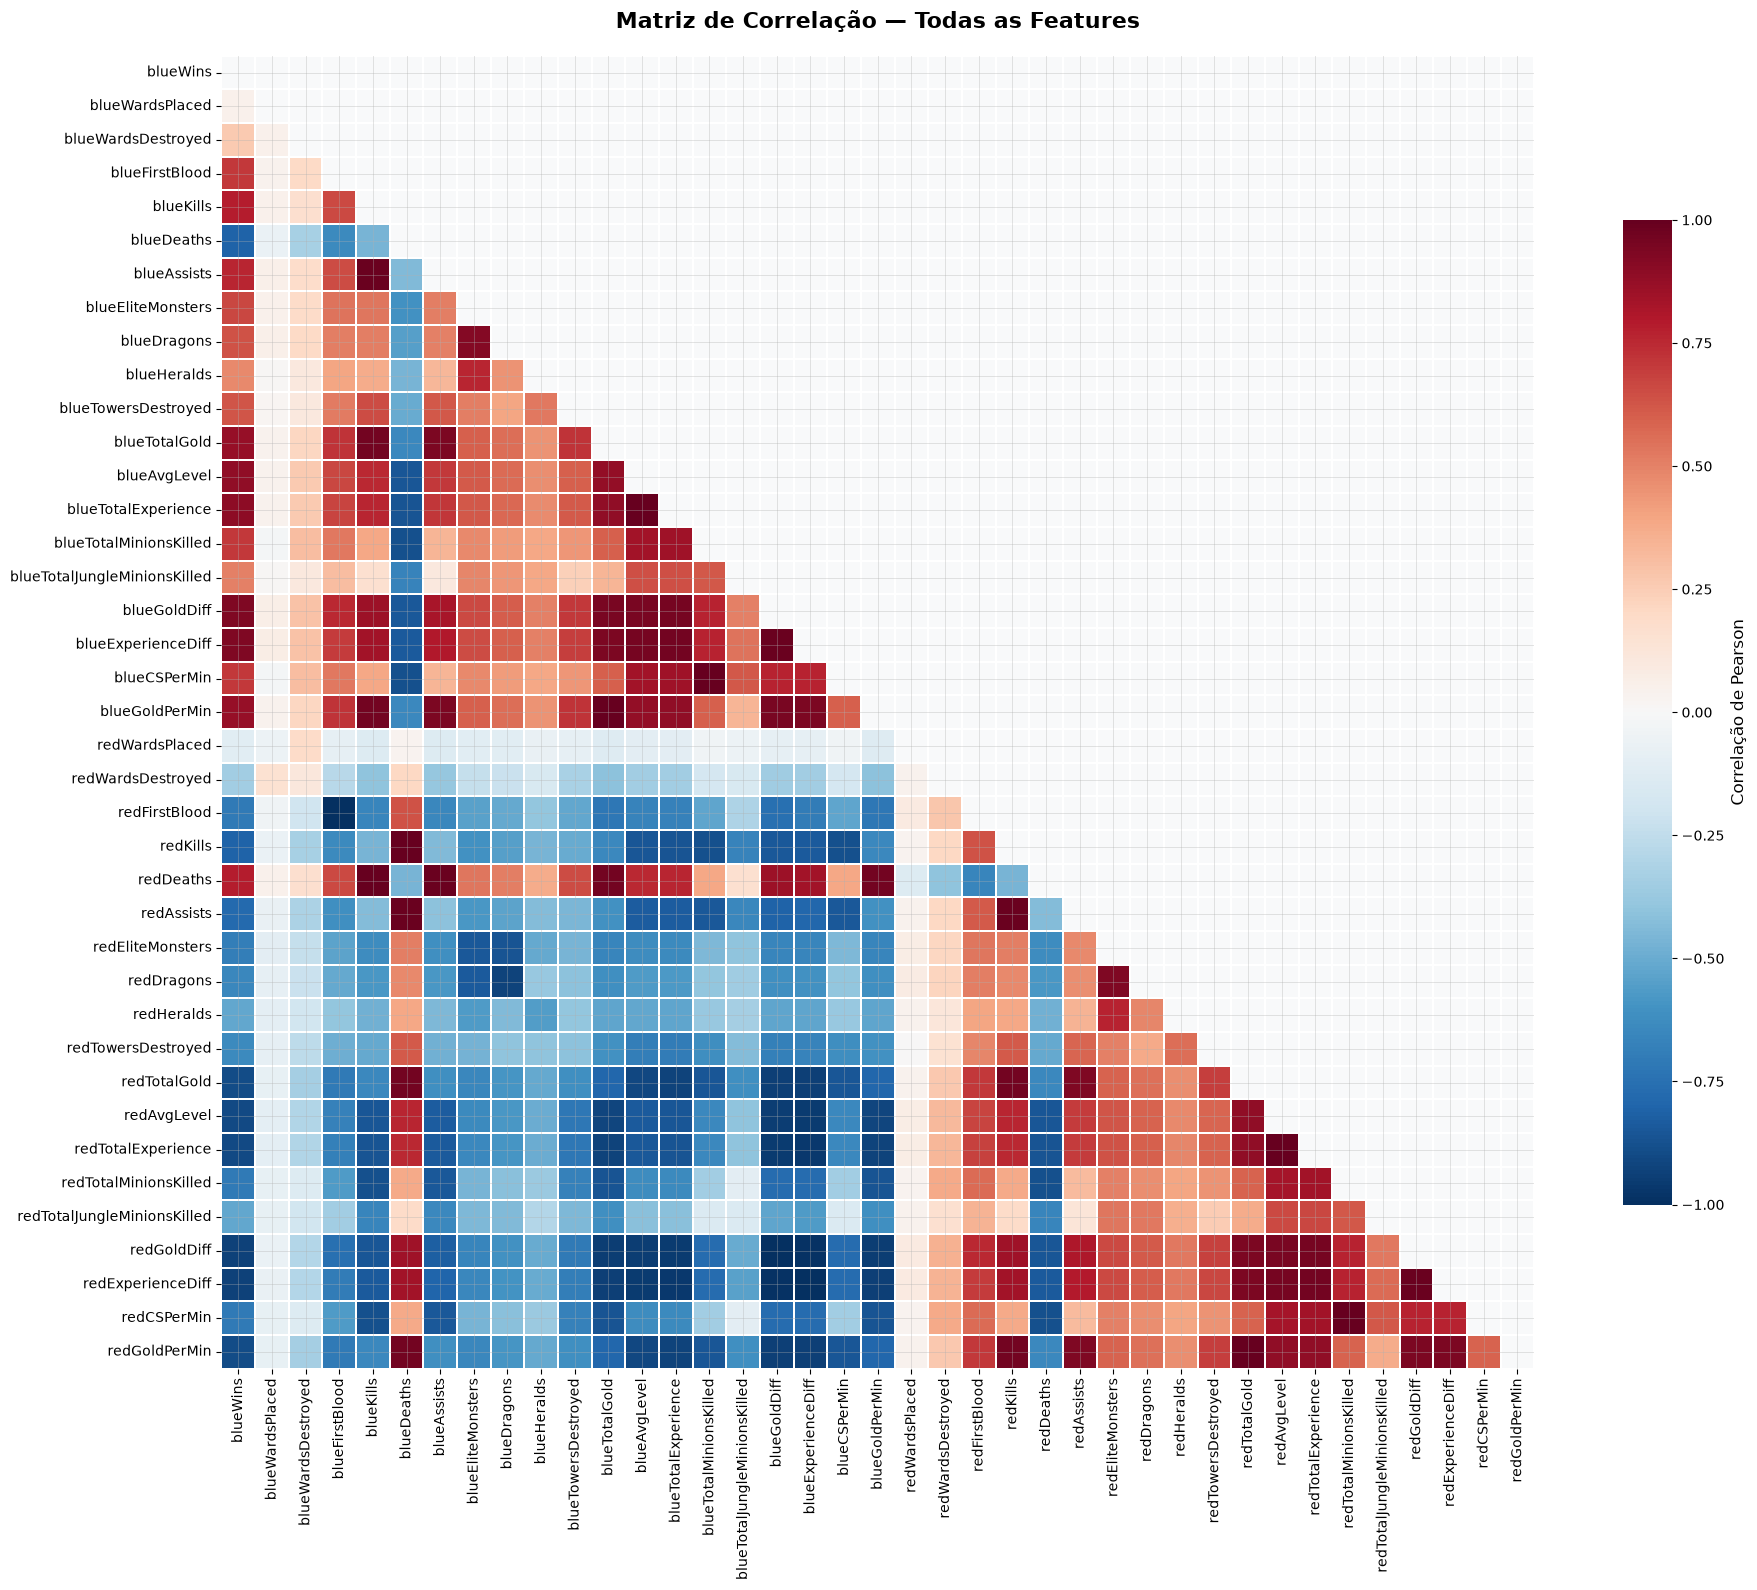

In [91]:
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar apenas triângulo inferior

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlação de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de Correlação — Todas as Features", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("reports/figures/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [92]:
# Observações
print("PARES COM ALTA CORRELAÇÃO POSITIVA (|r| > 0.85):")
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85 and corr.columns[i] != corr.columns[j]:
            high_corr.append((corr.columns[i], corr.columns[j], val))
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

for a, b, v in high_corr[:10]:
    print(f"  {a} <-> {b}: {v:.3f}")

PARES COM ALTA CORRELAÇÃO POSITIVA (|r| > 0.85):
  blueFirstBlood <-> redFirstBlood: -1.000
  blueKills <-> redDeaths: 1.000
  blueDeaths <-> redKills: 1.000
  blueTotalGold <-> blueGoldPerMin: 1.000
  blueTotalMinionsKilled <-> blueCSPerMin: 1.000
  blueGoldDiff <-> redGoldDiff: -1.000
  blueExperienceDiff <-> redExperienceDiff: -1.000
  redTotalGold <-> redGoldPerMin: 1.000
  redTotalMinionsKilled <-> redCSPerMin: 1.000
  redAvgLevel <-> redTotalExperience: 0.998


## Correlação de cada feature com a target

In [93]:
corr_target = (
    df.drop(columns=["gameId"])
    .corr()["blueWins"]
    .drop("blueWins")
    .sort_values(ascending=False)
)

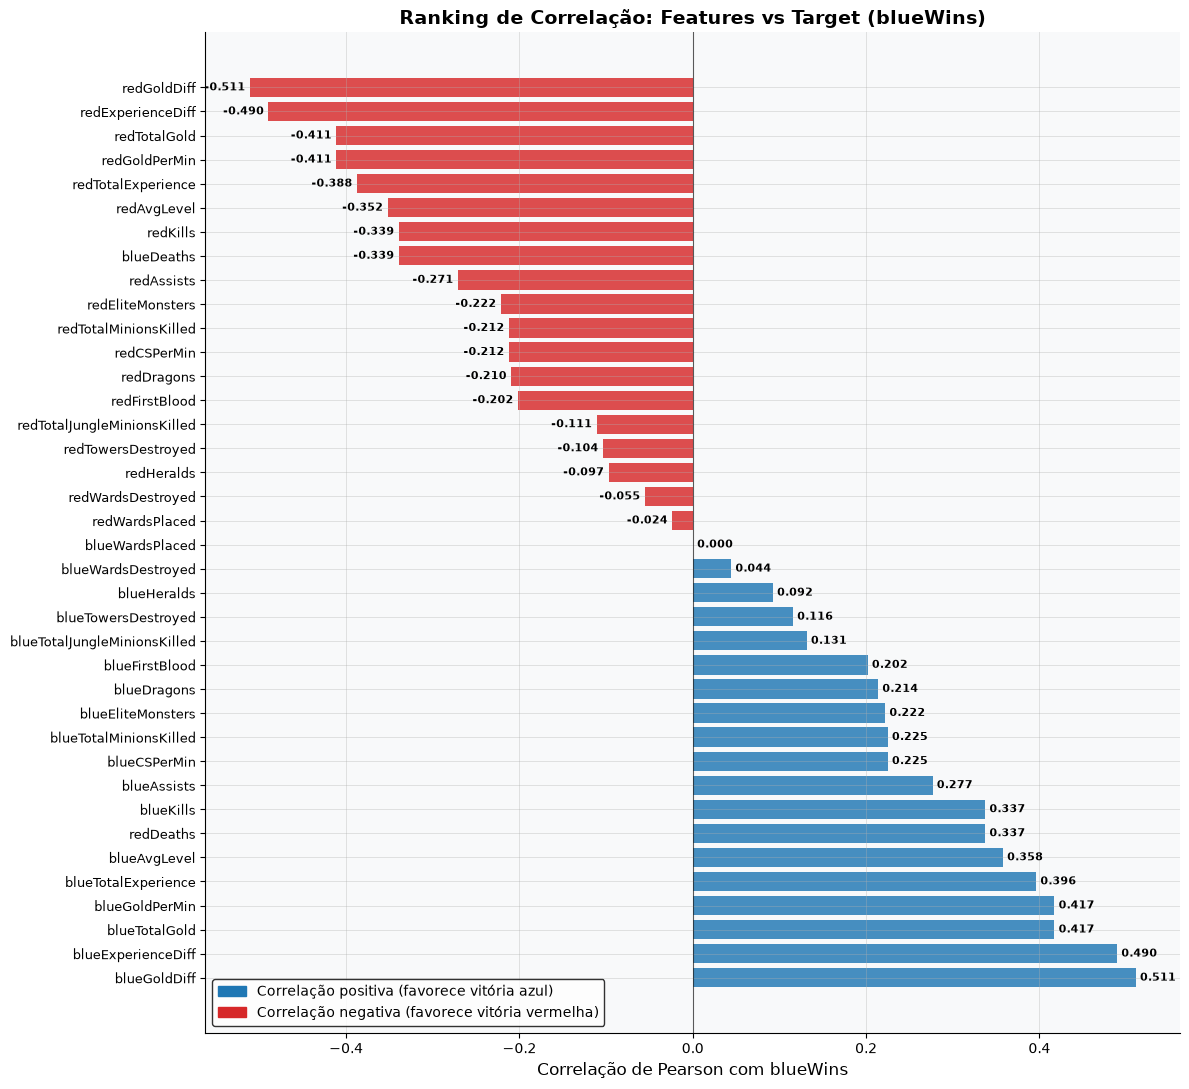

In [94]:
fig, ax = plt.subplots(figsize=(12, 11))
colors_bar = [BLUE if v >= 0 else RED for v in corr_target.values]
bars = ax.barh(
    range(len(corr_target)), corr_target.values, color=colors_bar, alpha=0.82
)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index, fontsize=9.5)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Correlação de Pearson com blueWins")
ax.set_title("Ranking de Correlação: Features vs Target (blueWins)")

# Valores nas barras
for i, (bar, val) in enumerate(zip(bars, corr_target.values)):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(
        val + offset,
        i,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8,
        fontweight="bold",
    )

blue_patch = mpatches.Patch(
    color=BLUE, label="Correlação positiva (favorece vitória azul)"
)
red_patch = mpatches.Patch(
    color=RED, label="Correlação negativa (favorece vitória vermelha)"
)
ax.legend(
    handles=[blue_patch, red_patch],
    loc="lower left",
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="black",
)

plt.tight_layout()
plt.savefig(
    "reports/figures/03_feature_correlation_target.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [96]:
print("TOP 5 PREDITORES POSITIVOS (favorecem vitória do Time Azul):")
for feat, val in corr_target.head(5).items():
    print(f"  {feat}: {val:+.4f}")
print()
print("TOP 5 PREDITORES NEGATIVOS (favorecem vitória do Time Vermelho):")
for feat, val in corr_target.tail(5).items():
    print(f"  {feat}: {val:+.4f}")

TOP 5 PREDITORES POSITIVOS (favorecem vitória do Time Azul):
  blueGoldDiff: +0.5111
  blueExperienceDiff: +0.4896
  blueTotalGold: +0.4172
  blueGoldPerMin: +0.4172
  blueTotalExperience: +0.3961

TOP 5 PREDITORES NEGATIVOS (favorecem vitória do Time Vermelho):
  redTotalExperience: -0.3876
  redGoldPerMin: -0.4114
  redTotalGold: -0.4114
  redExperienceDiff: -0.4896
  redGoldDiff: -0.5111


## Win Rate por Conquistas-Chave (features binárias)

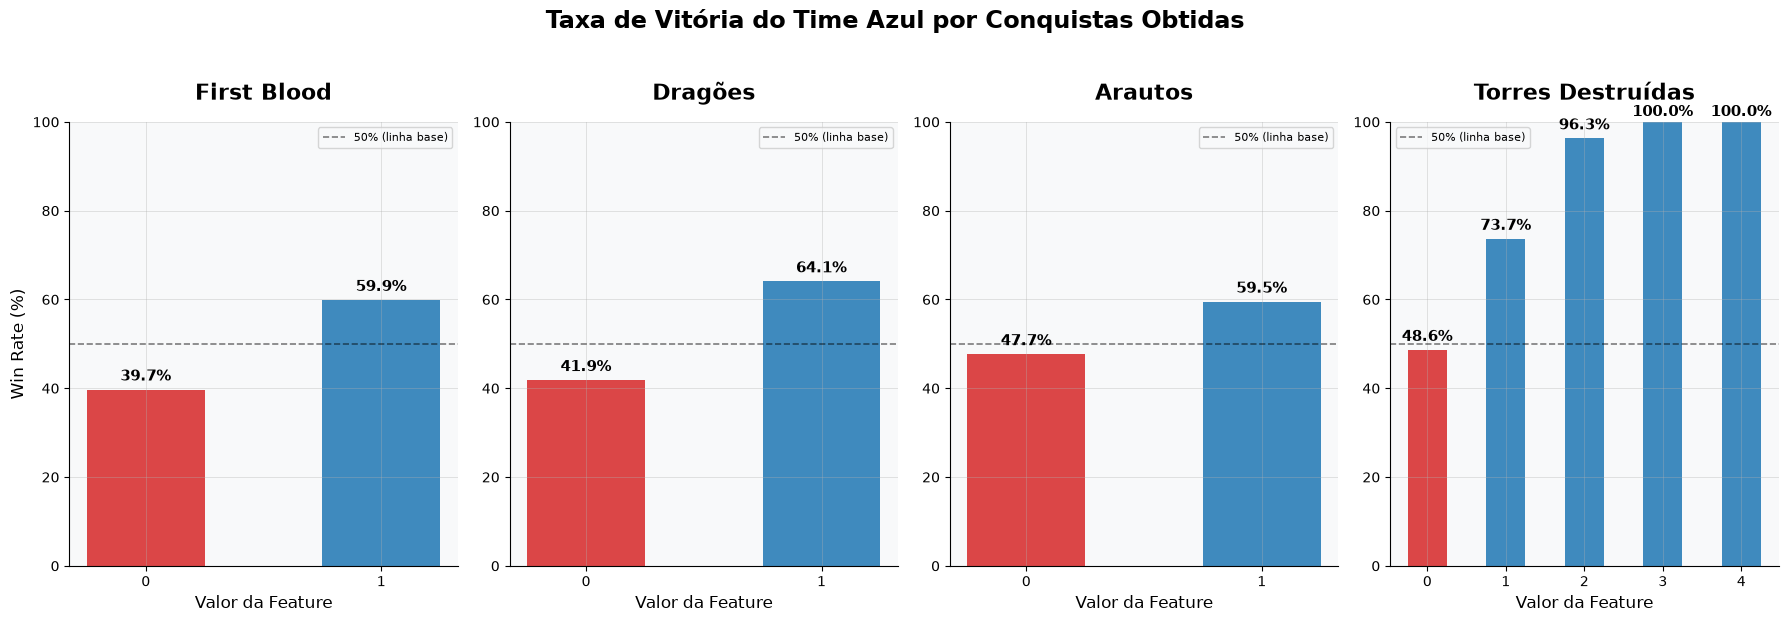

In [99]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

binary_features = {
    "blueFirstBlood": ("First Blood", axes[0]),
    "blueDragons": ("Dragões", axes[1]),
    "blueHeralds": ("Arautos", axes[2]),
    "blueTowersDestroyed": ("Torres Destruídas", axes[3]),
}

for feat, (titulo, ax) in binary_features.items():
    wr = df.groupby(feat)["blueWins"].mean() * 100
    vals = sorted(df[feat].unique())

    bar_colors = [BLUE if wr.get(v, 50) >= 50 else RED for v in vals]

    bars = ax.bar(
        [str(int(v)) for v in vals],
        [wr.get(v, 0) for v in vals],
        color=bar_colors,
        alpha=0.85,
        width=0.5,
    )

    ax.axhline(
        50,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.5,
        label="50% (linha base)",
    )

    ax.set_ylim(0, 100)

    ax.set_ylabel("Win Rate (%)" if feat == "blueFirstBlood" else "")
    ax.set_xlabel("Valor da Feature")

    # Afasta o título do gráfico
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=16,
    )

    ax.legend(fontsize=8)

    # Valores nas barras
    for bar, v in zip(bars, [wr.get(vv, 0) for vv in vals]):
        y = min(bar.get_height() + 1.2, 100.5)

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

plt.suptitle(
    "Taxa de Vitória do Time Azul por Conquistas Obtidas",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()

plt.savefig(
    "reports/figures/04_win_rate_binary_features.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Boxplots: features contínuas por resultado

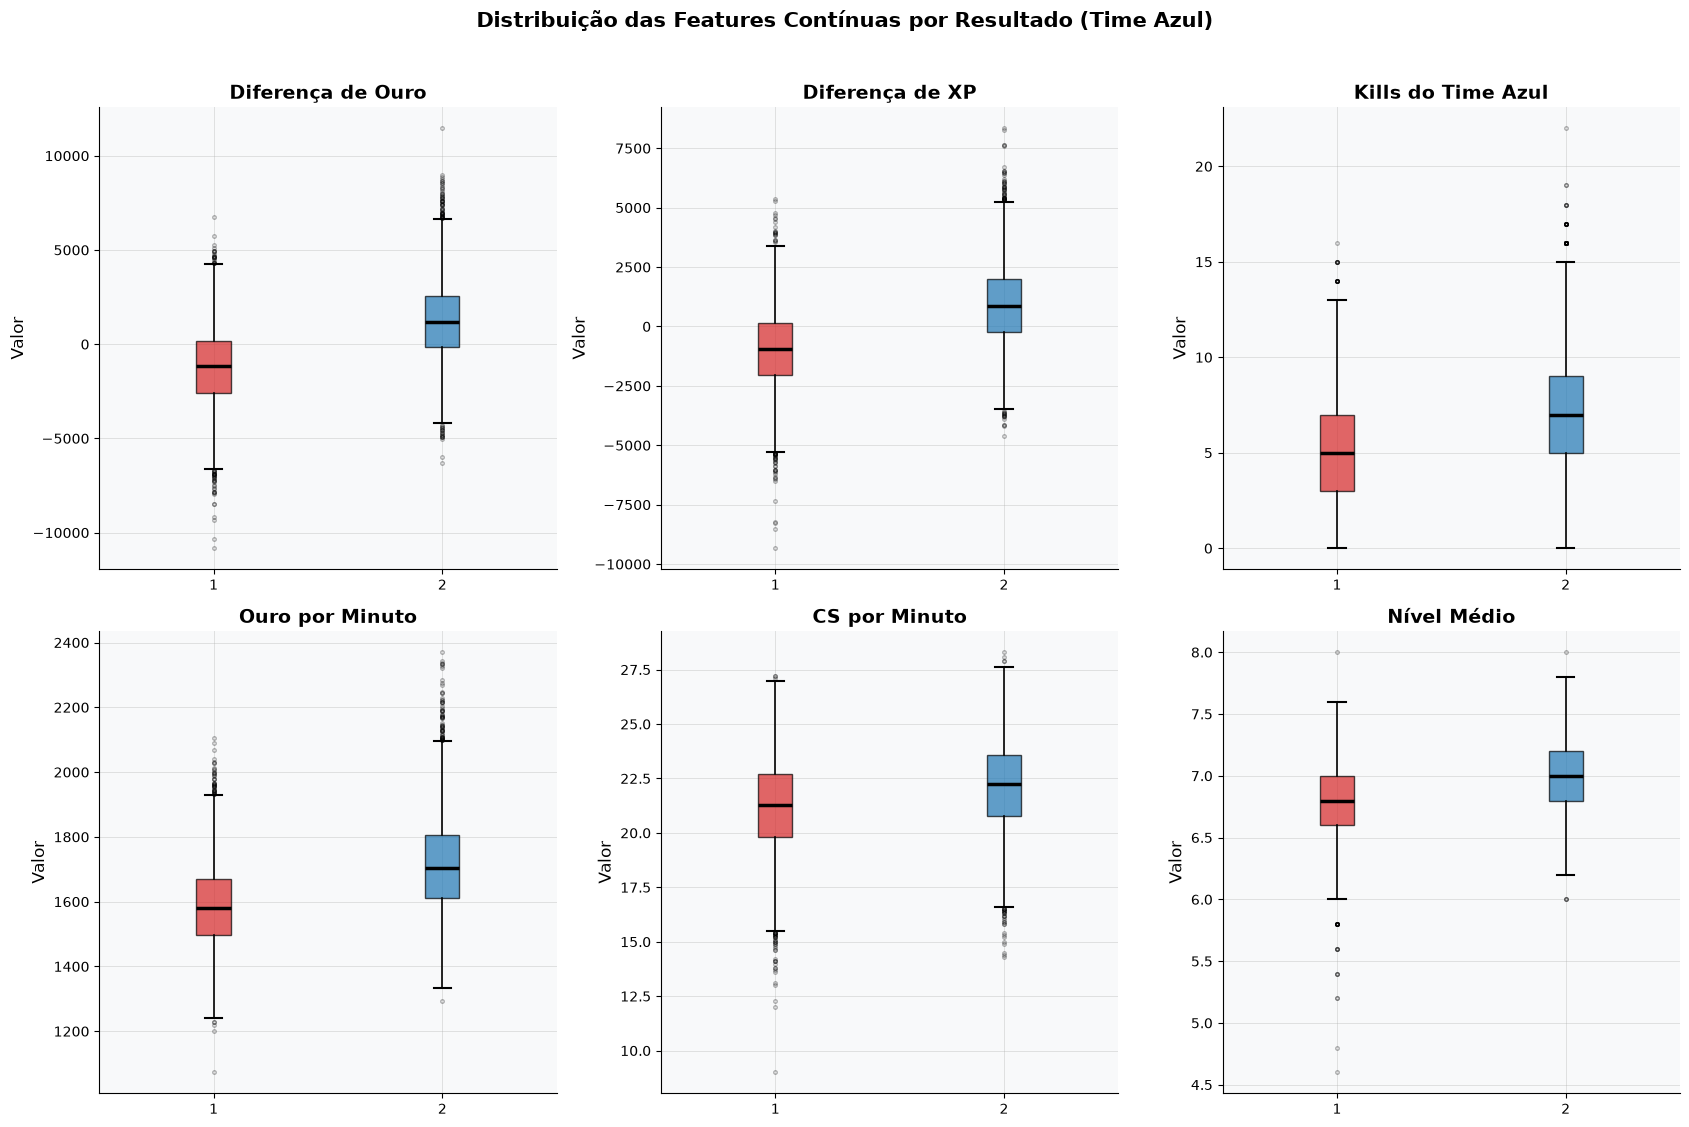

In [101]:
feats_box = [
    ("blueGoldDiff", "Diferença de Ouro"),
    ("blueExperienceDiff", "Diferença de XP"),
    ("blueKills", "Kills do Time Azul"),
    ("blueGoldPerMin", "Ouro por Minuto"),
    ("blueCSPerMin", "CS por Minuto"),
    ("blueAvgLevel", "Nível Médio"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for i, (feat, titulo) in enumerate(feats_box):
    ax = axes[i]
    data_perde = df[df["blueWins"] == 0][feat]
    data_vence = df[df["blueWins"] == 1][feat]

    bp = ax.boxplot(
        [data_perde, data_vence],
        label=["Derrota (0)", "Vitória (1)"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=2.5, alpha=0.3),
    )
    bp["boxes"][0].set_facecolor(RED)
    bp["boxes"][1].set_facecolor(BLUE)
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_alpha(0.7)

    ax.set_title(titulo)
    ax.set_ylabel("Valor")

plt.suptitle(
    "Distribuição das Features Contínuas por Resultado (Time Azul)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    "reports/figures/05_boxplots_continuous_features.png", dpi=150, bbox_inches="tight"
)

## Gold Diff e XP Diff: distribuição por resultado

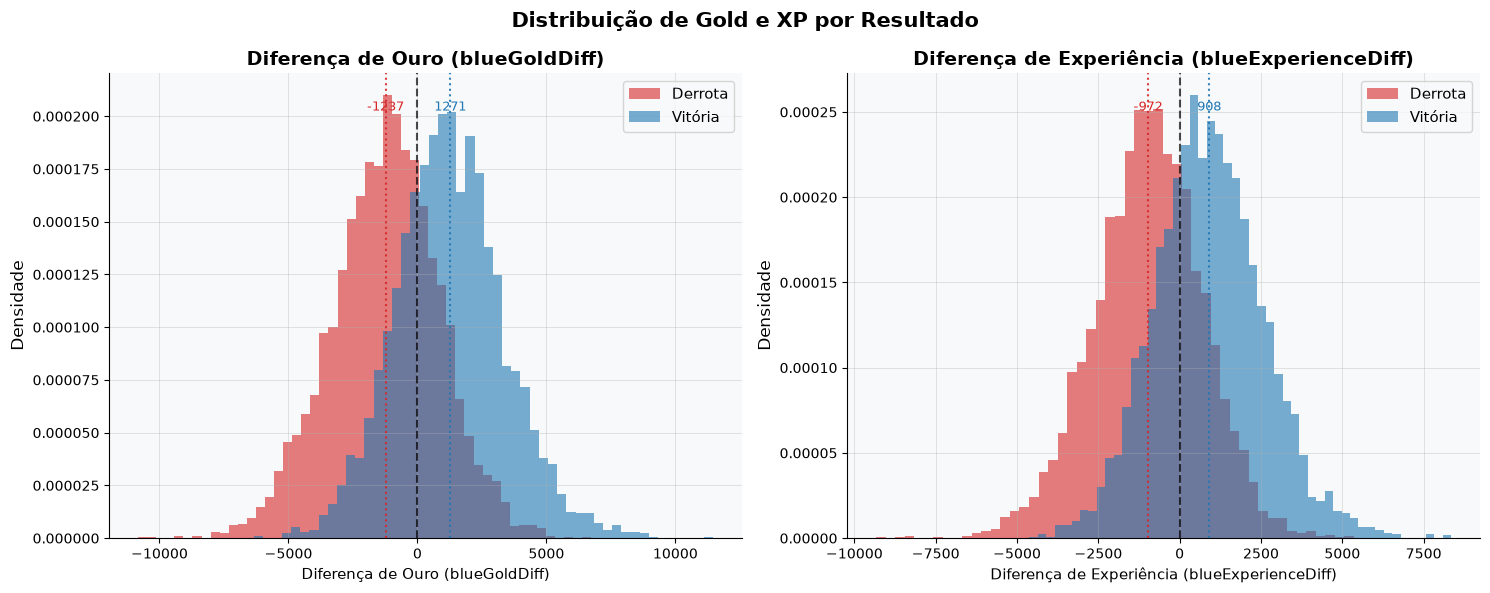

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (feat, titulo) in zip(
    axes,
    [
        ("blueGoldDiff", "Diferença de Ouro (blueGoldDiff)"),
        ("blueExperienceDiff", "Diferença de Experiência (blueExperienceDiff)"),
    ],
):
    for win_val, cor, label in [(0, RED, "Derrota"), (1, BLUE, "Vitória")]:
        subset = df[df["blueWins"] == win_val][feat]
        ax.hist(subset, bins=50, alpha=0.6, color=cor, label=label, density=True)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel(titulo, fontsize=11)
    ax.set_ylabel("Densidade")
    ax.set_title(titulo)
    ax.legend()
    # Anotações de média
    for win_val, cor in [(0, RED), (1, BLUE)]:
        mean_val = df[df["blueWins"] == win_val][feat].mean()
        ax.axvline(mean_val, color=cor, linewidth=1.5, linestyle=":", alpha=0.9)
        ax.text(
            mean_val,
            ax.get_ylim()[1] * 0.92,
            f"{mean_val:.0f}",
            color=cor,
            ha="center",
            fontsize=9,
        )

plt.suptitle("Distribuição de Gold e XP por Resultado", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "reports/figures/06_gold_xp_diff_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [103]:
print("MÉDIAS DE GOLD DIFF:")
print(f"  Time Azul PERDE: {df[df['blueWins'] == 0]['blueGoldDiff'].mean():,.0f}")
print(f"  Time Azul VENCE: {df[df['blueWins'] == 1]['blueGoldDiff'].mean():,.0f}")

MÉDIAS DE GOLD DIFF:
  Time Azul PERDE: -1,237
  Time Azul VENCE: 1,271


## Comparação Blue vs Red: tem vantagem de lado?

In [104]:
# Verificar se jogar pelo lado azul dá alguma vantagem estrutural
comparacoes = [
    ("blueKills", "redKills", "Kills"),
    ("blueWardsPlaced", "redWardsPlaced", "Wards Colocadas"),
    ("blueTotalGold", "redTotalGold", "Ouro Total"),
    ("blueAvgLevel", "redAvgLevel", "Nível Médio"),
]

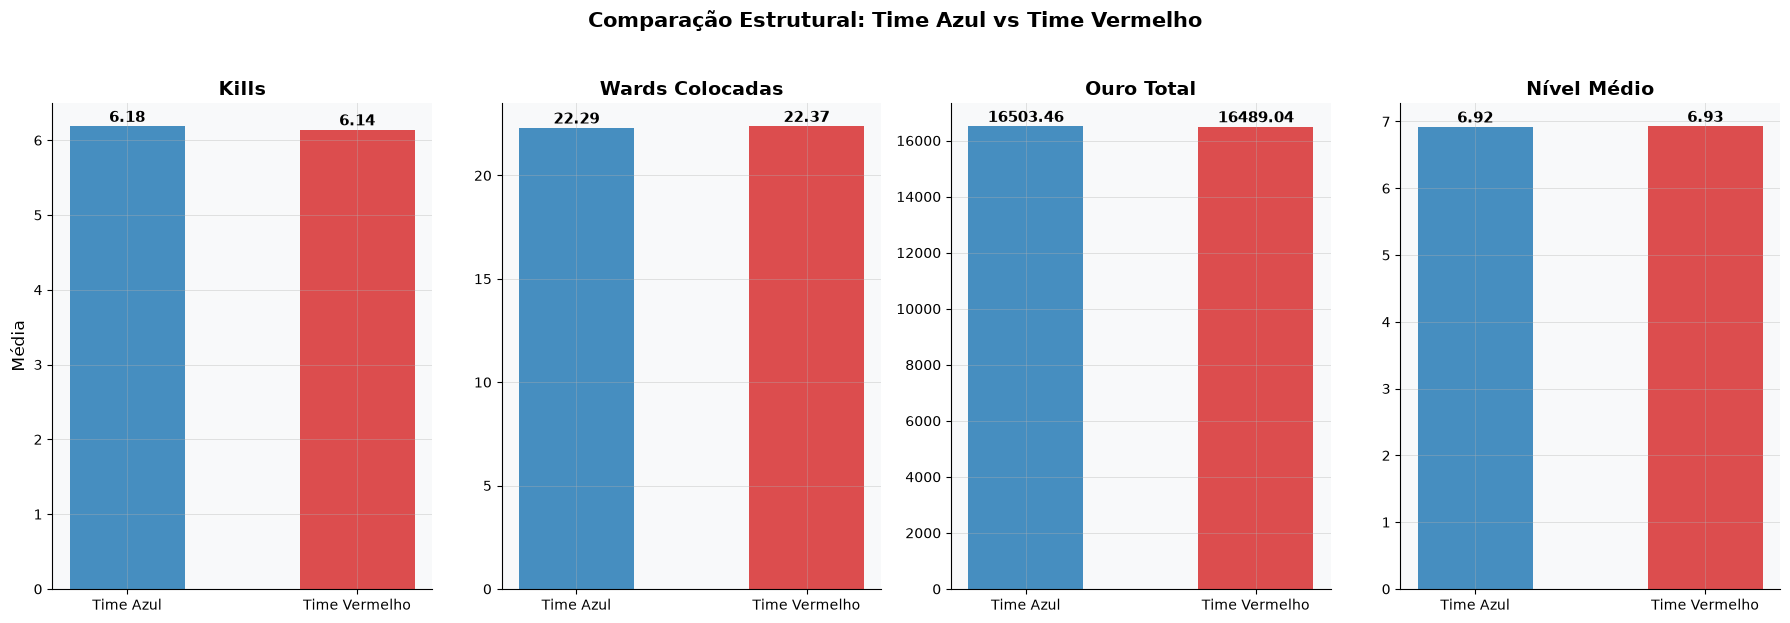

In [105]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, (blue_col, red_col, titulo) in zip(axes, comparacoes):
    blue_mean = df[blue_col].mean()
    red_mean = df[red_col].mean()
    ax.bar(
        ["Time Azul", "Time Vermelho"],
        [blue_mean, red_mean],
        color=[BLUE, RED],
        alpha=0.82,
        width=0.5,
    )
    ax.set_title(titulo)
    ax.set_ylabel("Média" if titulo == "Kills" else "")
    for i, v in enumerate([blue_mean, red_mean]):
        ax.text(
            i, v + v * 0.01, f"{v:.2f}", ha="center", fontweight="bold", fontsize=11
        )

plt.suptitle(
    "Comparação Estrutural: Time Azul vs Time Vermelho",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.savefig(
    "reports/figures/07_blue_vs_red_comparison.png", dpi=150, bbox_inches="tight"
)


In [107]:
print(f"Win rate geral do Time Azul: {df['blueWins'].mean():.1%}")

Win rate geral do Time Azul: 49.9%


Conclusão: as médias são praticamente simétricas — sem vantagem estrutural de lado.

1. **Dataset perfeitamente balanceado**: 49.9% azul / 50.1% vermelho. Sem necessidade de técnicas de rebalanceamento.
2. **`blueGoldDiff` e `blueExperienceDiff` são os maiores preditores** de vitória — quem domina ouro e XP nos primeiros minutos tem vantagem enorme.
3. **First Blood importa**: times que obtêm o primeiro abate vencem em ~56% das partidas.
4. **Dragões e Arautos**: cada objetivo capturado eleva consistentemente a win rate.
5. **Multicolinearidade detectada**: colunas espelho (ex: `redDeaths` = `blueKills`) — serão removidas na preparação.
6. **Sem vantagem de lado**: as médias entre blue e red são quase idênticas. O jogo é simétrico.